<a href="https://colab.research.google.com/github/Ishalllll/preconception-stunting-risk-screening/blob/main/notebooks/modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import datetime as _dt
import jupyter_client.session as _jcs

# utcnow() adalah fungsi level-modul yang dipanggil lewat nama global
# di dalam msg_header(), jadi mengganti atribut modul langsung berlaku
# untuk semua pemanggilan berikutnya.
_jcs.utcnow = lambda: _dt.datetime.now(_dt.timezone.utc)

# Load & Reformatting

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import math
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,average_precision_score, roc_auc_score
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [5]:
df_raw = pd.read_csv("dataset_stunting.csv")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
# Missing value reformatting
missing_reformatting_columns = ["jumlah_kamar","bahan_lantai","bahan_dinding","bahan_atap"]
missing_code = [98,95]

# Replace value
for col in missing_reformatting_columns:
  df_raw[col] = df_raw[col].replace(missing_code, np.nan)

# Verify sisa kode 95/98
for col in missing_reformatting_columns:
    sisa = df_raw[col].isin([95, 98]).sum()
    print(f"{col}: {sisa}")

jumlah_kamar: 0
bahan_lantai: 0
bahan_dinding: 0
bahan_atap: 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Exploratory Data Analysis

Records	: 5115
Columns	: 45
Duplicated	: 0
Dataframe Values: 


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5115.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5044.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5017.
  res = hypotest_fun_out(*samples, **kwds)
/usr

,Columns,Data Types,Unique,Missing Values,Missing Values(%),Distributions,Outliers,Unique Values
0,pidlink,int64,5115,0,0.00,Non-normal,0,"[1060010, 1065104, 1085107, 1224106, 1240023, ..."
9,urban,int64,2,0,0.00,Non-normal,0,"[0, 1]"
33,stunting,int64,2,0,0.00,Non-normal,0,"[1, 0]"
1,hhid14,int64,4590,0,0.00,Non-normal,0,"[10600, 10651, 10851, 12241, 12400, 12500, 202..."
41,air_mck_kode,float64,10,1,0.02,Non-normal,384,"[4.0, 3.0, 7.0, 2.0, 95.0, 1.0, 6.0, 5.0, 8.0,..."
32,listrik,float64,2,1,0.02,Non-normal,44,"[0.0, 1.0, nan]"
25,bahan_atap,float64,6,18,0.35,Non-normal,111,"[3.0, 6.0, 4.0, 5.0, 1.0, nan, 2.0]"
26,air_minum_layak,float64,3,70,1.37,Non-normal,953,"[1.0, 2.0, 0.0, nan]"
27,air_mck_layak,float64,3,75,1.47,Non-normal,1249,"[1.0, 0.0, 2.0, nan]"
28,air_mck_sama,float64,2,1,0.02,Non-normal,0,"[1.0, 0.0, nan]"



Descriptive Statistics (Numeric Data Types):


,pidlink,hhid14,pid_ibu,pid_ayah,ibu_tinggi,ibu_pendidikan,ayah_pendidikan,ibu_usia_konsepsi,ayah_tinggi,urban,ibu_bekerja,ayah_bekerja,ayah_merokok,umur_bulan,jenis_kelamin,limbah_dekat_rumah,tumpukan_sampah,air_tergenang,dekat_kandang,ventilasi_cukup,dapur_kamar_menyatu,luas_rumah_m2,jumlah_kamar,bahan_lantai,bahan_dinding,bahan_atap,air_minum_layak,air_mck_layak,air_mck_sama,jamban_layak,limbah_aman,sampah_aman,listrik,stunting,haz,_tinggi,_tinggi_k,_berat,_metode,ibu_umur,air_minum_kode,air_mck_kode,jamban_kode,limbah_kode,sampah_kode
count,5.115000e+03,5.115000e+03,5.044000e+03,4.616000e+03,4917.000000,5017.000000,4577.000000,5037.000000,3982.000000,5115.000000,5033.000000,4589.000000,4271.000000,5115.000000,5115.000000,5115.000000,5115.000000,5115.000000,5115.000000,5115.000000,5115.000000,14.000000,5114.000000,5112.000000,5076.000000,5097.000000,5045.000000,5040.000000,5114.000000,5073.000000,5114.000000,5114.000000,5114.000000,5115.000000,5115.000000,5115.000000,5115.000000,5111.000000,5115.000000,5037.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000
mean,1.581857e+08,1.581857e+06,1.582025e+08,1.564287e+08,151.717063,2.455053,2.458160,26.654672,163.407760,0.577713,0.484204,0.989758,0.789511,29.861779,1.961877,2.829521,2.797067,2.796676,2.533920,1.287390,2.910850,8.148214,5.643919,2.095070,1.245272,3.773004,1.798216,1.704762,0.544388,1.591563,0.718224,0.828119,0.991396,0.285630,-0.939548,85.150303,85.192727,11.681119,1.670968,29.887830,6.443488,3.641572,2.420806,3.412006,3.119671
std,1.007993e+08,1.007993e+06,1.009221e+08,1.016921e+08,5.390478,1.023460,1.027191,5.927302,6.043034,0.493972,0.499800,0.100694,0.407704,17.152479,0.999371,0.558530,0.603949,0.604465,0.845618,0.701629,0.412777,3.681529,2.297652,1.276014,0.495027,0.739442,0.432287,0.550431,0.498075,0.748779,0.449908,0.377314,0.092366,0.451758,1.844291,13.793435,13.766352,3.815794,0.944411,6.039643,11.051399,11.158881,8.459547,9.434540,10.169988
min,1.060010e+06,1.060000e+04,1.060004e+06,1.060001e+06,125.800000,0.000000,0.000000,13.166667,128.500000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.050000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.000000,43.600000,43.600000,2.000000,1.000000,15.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,5.813256e+07,5.813255e+05,5.808308e+07,5.614001e+07,148.000000,2.000000,2.000000,22.166667,159.400000,0.000000,0.000000,1.000000,1.000000,15.000000,1.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,9.996250,4.000000,1.000000,1.000000,3.000000,2.000000,2.000000,0.000000,2.000000,0.000000,1.000000,1.000000,0.000000,-2.160000,75.100000,75.100000,9.000000,1.000000,25.000000,2.000000,2.000000,1.000000,1.000000,1.000000
50%,1.601151e+08,1.601151e+06,1.601100e+08,1.580300e+08,151.600000,3.000000,3.000000,26.500000,163.300000,1.000000,0.000000,1.000000,1.000000,30.000000,1.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,9.998000,5.000000,2.000000,1.000000,4.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000,-1.180000,86.200000,86.300000,11.400000,1.000000,30.000000,3.000000,2.000000,1.000000,1.000000,2.000000
75%,2.571326e+08,2.571326e+06,2.573950e+08,2.580550e+08,155.300000,3.000000,3.000000,30.666667,167.400000,1.000000,1.000000,1.000000,1.000000,45.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,9.998000,7.000000,3.000000,1.000000,4.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.060000,95.600000,95.600000,13.900000,3.000000,34.000000,10.000000,3.000000,2.000000,4.000000,2.000000
max,3.212653e+08,3.212653e+06,3.212600e+08,3.212653e+08,174.500000,4.000000,4.000000,50.000000,198.000000,1.000000,1.000000,1.000000,1.000000,59.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,9.998000,40.000000,6.000000,3.000000,6.000000,2.000000,2.000000,1.000000,2.000000,1


Target Class Distribution:
0    3654 (71.4 %)
1    1461 (28.6 %)

Distributions Visualization (Numeric Data Types):


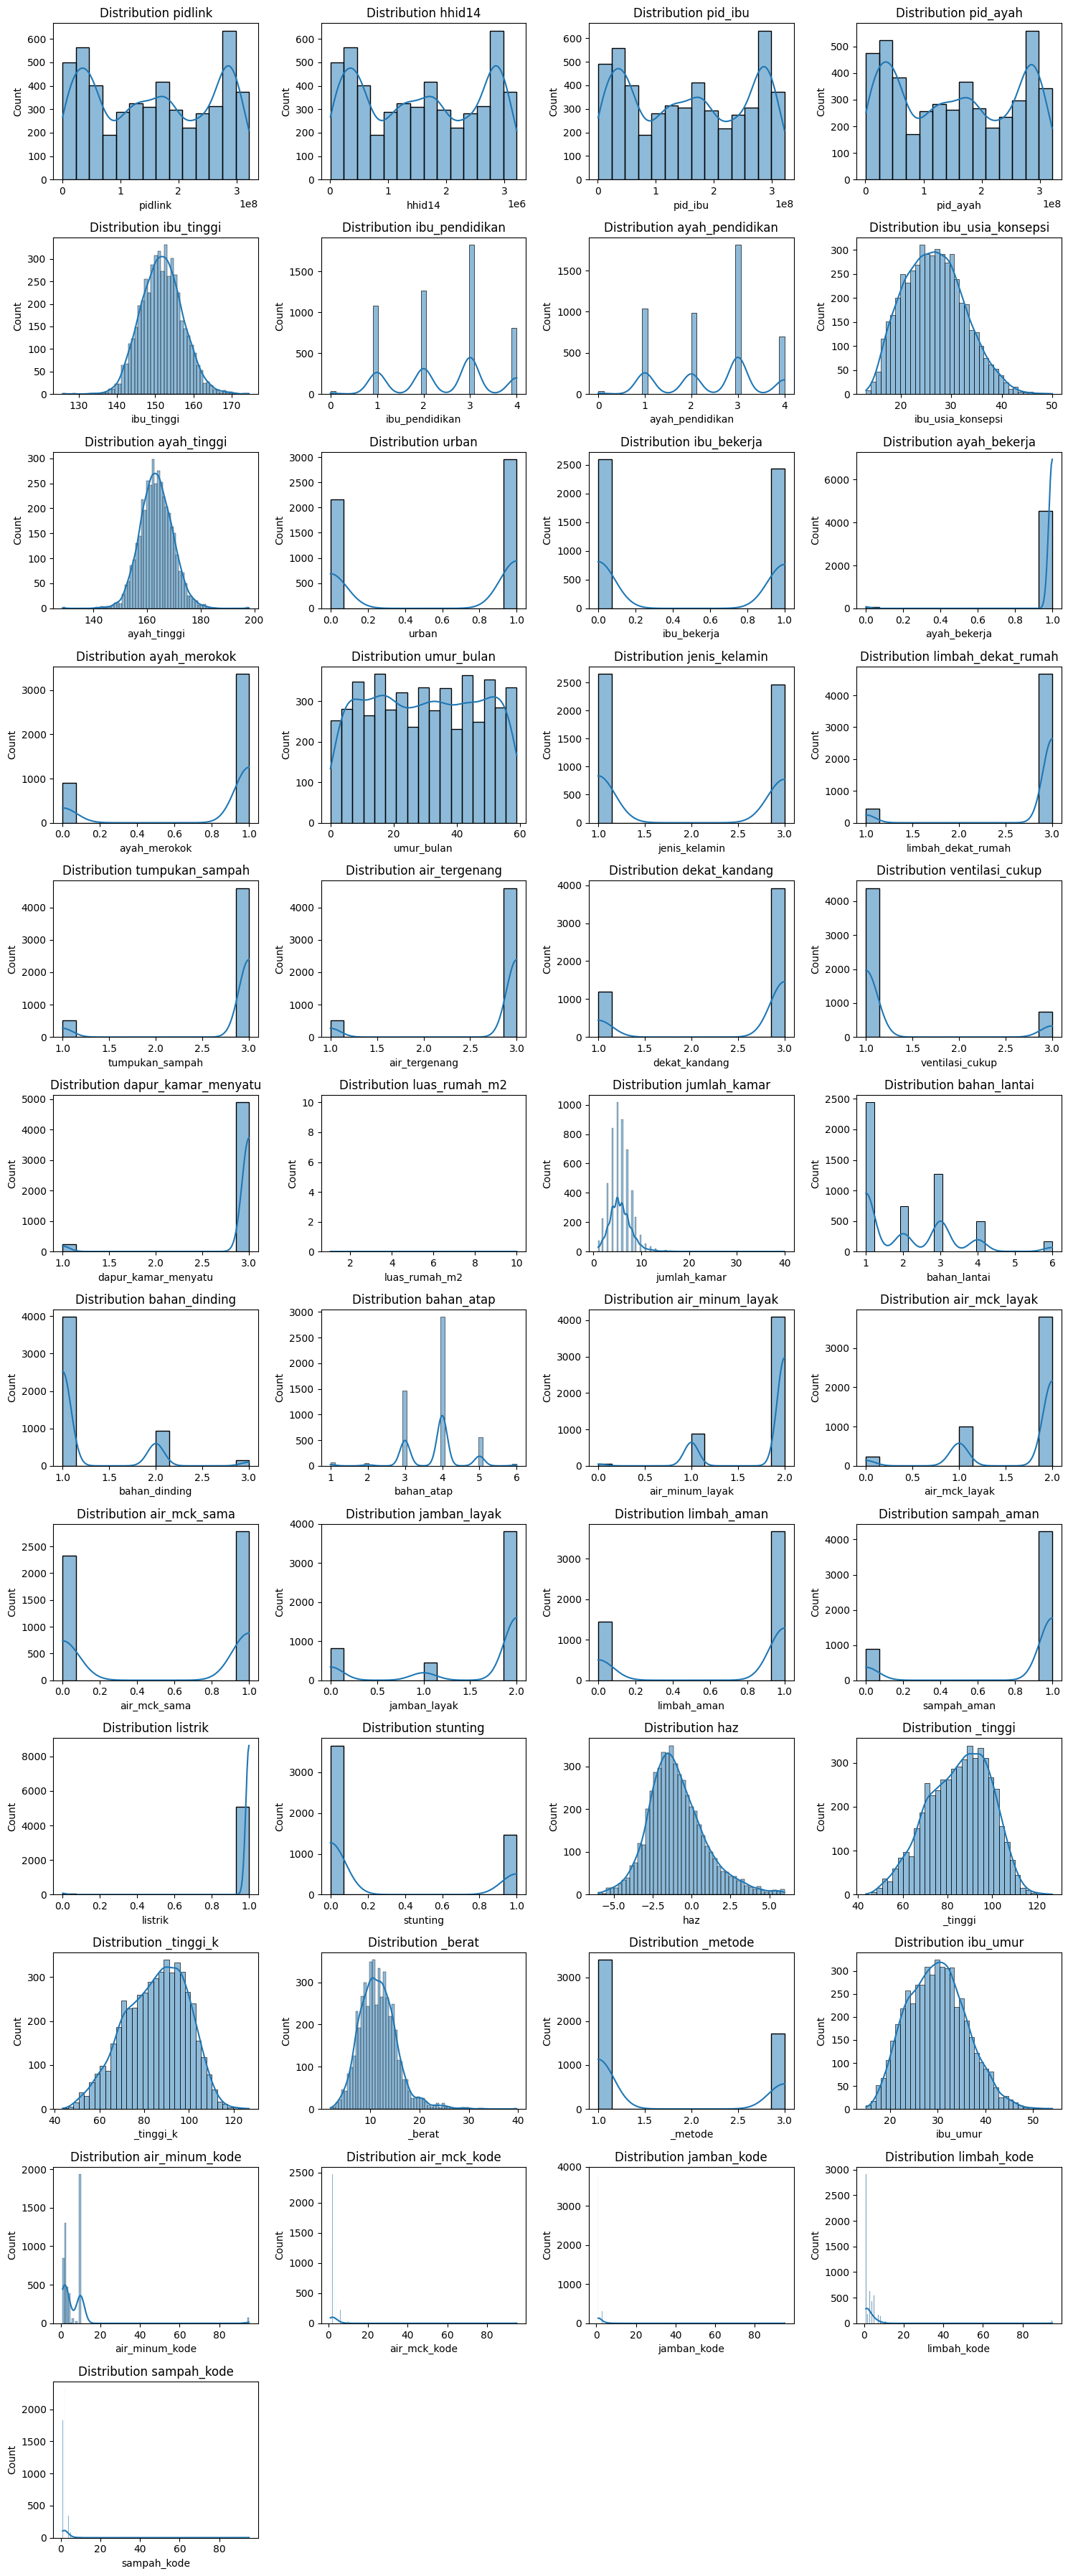

In [7]:
def data_understanding(df, kolom_target):
  prepare = []
  for column in df.columns:
    # Identifikasi missing values
    percent_missing = (df[column].isnull().sum()/len(df[column]))*100

    # Identifikasi bentuk distribusi
    if pd.api.types.is_numeric_dtype(df[column]):
      stat_,p_value = stats.shapiro(df[column].dropna())
      distrib = "Normal" if p_value > 0.05 else "Non-normal"
    else:
      distrib = '-'

    # Identifikasi outliers
    if pd.api.types.is_numeric_dtype(df[column]):
      q1 = np.quantile(df[column].dropna(),0.25)
      q3 = np.quantile(df[column].dropna(),0.75)
      iqr = q3 - q1

      delta = 1.5 * iqr
      lower_bound = q1 - delta
      upper_bound = q3 + delta
      outliers = (df[column] < lower_bound) | (df[column] > upper_bound)
      outliers_sum = df[column][outliers].count()
    else:
      outliers_sum = '-'

    prepare.append(
        [
            column,
            df[column].dtype,
            df[column].nunique(),
            df[column].isnull().sum(),
            f"{percent_missing:.2f}",
            distrib,
            outliers_sum,
            df[column].unique()
        ]
    )
  print(f"Records\t: {df.shape[0]}")
  print(f"Columns\t: {df.shape[1]}")

  print(f"Duplicated\t: {df.duplicated().sum()}")
  print('Dataframe Values: ')
  dfv = pd.DataFrame(prepare,columns = ['Columns','Data Types','Unique','Missing Values','Missing Values(%)','Distributions','Outliers','Unique Values'])
  dfv['Data Types'] = dfv['Data Types'].astype(str)
  display(dfv.sort_values("Data Types", ascending = False))

  print(f"="*180,"\n")
  print('Descriptive Statistics (Numeric Data Types):')
  pd.set_option('display.max_columns', None)
  display(df.describe())
  pd.reset_option('display.max_columns')

  print(f"="*180,"\n")
  # Target label distributions
  print("Target Class Distribution:")
  counts = df[f'{kolom_target}'].value_counts()
  percentages = df[f'{kolom_target}'].value_counts(normalize=True) * 100
  for index, count in counts.items():
      print(f'{index}    {count} ({percentages[index]:.1f} %)')

  print(f"="*180,"\n")
  print('Distributions Visualization (Numeric Data Types):')
  numeric_cols = df.select_dtypes(include='number').columns

  cols_per_row = 4
  n_cols = len(numeric_cols)
  n_rows = math.ceil(n_cols / cols_per_row)

  fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(15, 3 * n_rows))
  axes = axes.flatten()

  for i, col in enumerate(numeric_cols):
      sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
      axes[i].set_title(f'Distribution {col}')

  for j in range(i + 1, len(axes)):
      axes[j].set_visible(False)

  plt.tight_layout()
  plt.show()

data_understanding(df_raw,'stunting')

In [8]:
# Untuk tiap fitur numerik, bandingkan rata-ratanya pada anak
# stunting vs tidak stunting. Selisih besar = pembeda potensial.
d = df_raw
fitur_num = [
    "ibu_tinggi","ayah_tinggi","ibu_pendidikan","ayah_pendidikan",
    "ibu_usia_konsepsi","jumlah_kamar","air_minum_layak",
    "air_mck_layak","jamban_layak","urban","ibu_bekerja",
    "ayah_bekerja","ayah_merokok","listrik"
]

print("rata-rata fitur: stunting vs tidak")
print(f"{'fitur':22s} {'tidak':>8s} {'stunting':>10s} {'selisih':>9s}")
print("-"*52)
for columns in fitur_num + ["umur_bulan"]:
    g = d.groupby("stunting")[columns].mean()
    t, s = g.get(0, np.nan), g.get(1, np.nan)
    print(f"{columns:22s} {t:8.2f} {s:10.2f} {s-t:+9.2f}")

rata-rata fitur: stunting vs tidak
fitur                     tidak   stunting   selisih
----------------------------------------------------
ibu_tinggi               152.41     150.01     -2.40
ayah_tinggi              164.17     161.49     -2.67
ibu_pendidikan             2.56       2.20     -0.35
ayah_pendidikan            2.56       2.21     -0.34
ibu_usia_konsepsi         26.76      26.39     -0.37
jumlah_kamar               5.74       5.40     -0.35
air_minum_layak            1.83       1.73     -0.10
air_mck_layak              1.74       1.60     -0.14
jamban_layak               1.64       1.46     -0.18
urban                      0.60       0.51     -0.09
ibu_bekerja                0.49       0.47     -0.02
ayah_bekerja               0.99       0.99     -0.01
ayah_merokok               0.78       0.80     +0.02
listrik                    0.99       0.98     -0.01
umur_bulan                29.51      30.75     +1.24


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Preprocessing

In [9]:
df_clean = df_raw.copy()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Drop Columns & Rows

In [10]:
drop_cols = [
    # Pembentuk label / variabel sementara
    "_tinggi","_tinggi_k","_berat","haz", "_ayah_hilang","_berat","_tinggi","_tinggi_k",
    "_metode",
    # Turunan/bahan label
    "_metode","ibu_umur","umur_bulan", "jenis_kelamin",
    # Ada kolom yang lebih representatif: Kolom *_layak
    "air_minum_kode","air_mck_kode","jamban_kode","limbah_kode","sampah_kode",
    # Hanya ID
    "pidlink","hhid14","pid_ibu","pid_ayah",
    # Kondisi data hampir seragam (tidak ada informasi berharga) / missing hampir semua data / kode angka bukan urutan bagus
    "bahan_atap", "listrik", "ayah_bekerja","luas_rumah_m2"
]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
df_clean = df_clean.drop(
    columns=[c for c in drop_cols if c in df_clean.columns]
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Feature Engineering

In [13]:
# Binary reformatting: 1=yes, 3=no
biner_1_3 = ["limbah_dekat_rumah","tumpukan_sampah","air_tergenang","dekat_kandang","ventilasi_cukup","dapur_kamar_menyatu"]

for col in biner_1_3:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").map({1: 1, 3: 0})

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
float_cols = ["ibu_tinggi","ayah_tinggi","ibu_usia_konsepsi"]
non_float_cols = [i for i in df_clean.columns.tolist() if i not in float_cols]

for i in non_float_cols:
  df_clean[i] = df_clean[i].astype(int)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
# balik arah supaya konsisten: nilai tinggi kondisi lebih baik
df_clean["bahan_lantai"]  = 7 - df_clean["bahan_lantai"]
df_clean["bahan_dinding"] = 4 - df_clean["bahan_dinding"]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Records	: 3672
Columns	: 24
Duplicated	: 0
Dataframe Values: 


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Columns,Data Types,Unique,Missing Values,Missing Values(%),Distributions,Outliers,Unique Values
12,ventilasi_cukup,int64,2,0,0.00,Non-normal,509,"[1, 0]"
1,ibu_pendidikan,int64,5,0,0.00,Non-normal,27,"[0, 2, 1, 3, 4]"
22,sampah_aman,int64,2,0,0.00,Non-normal,632,"[0, 1]"
21,limbah_aman,int64,2,0,0.00,Non-normal,0,"[0, 1]"
20,jamban_layak,int64,3,0,0.00,Non-normal,0,"[0, 2, 1]"
19,air_mck_sama,int64,2,0,0.00,Non-normal,0,"[1, 0]"
18,air_mck_layak,int64,3,0,0.00,Non-normal,0,"[1, 0, 2]"
17,air_minum_layak,int64,3,0,0.00,Non-normal,732,"[1, 2, 0]"
16,bahan_dinding,int64,3,0,0.00,Non-normal,831,"[2, 3, 1]"
15,bahan_lantai,int64,6,0,0.00,Non-normal,0,"[1, 4, 5, 6, 3, 2]"



Descriptive Statistics (Numeric Data Types):


,ibu_tinggi,ibu_pendidikan,ayah_pendidikan,ibu_usia_konsepsi,ayah_tinggi,urban,ibu_bekerja,ayah_merokok,limbah_dekat_rumah,tumpukan_sampah,air_tergenang,dekat_kandang,ventilasi_cukup,dapur_kamar_menyatu,jumlah_kamar,bahan_lantai,bahan_dinding,air_minum_layak,air_mck_layak,air_mck_sama,jamban_layak,limbah_aman,sampah_aman,stunting
count,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000
mean,151.693573,2.453431,2.464325,26.739356,163.379711,0.573257,0.485566,0.788671,0.083061,0.099129,0.101580,0.238562,0.861383,0.045207,5.552288,4.876906,2.743736,1.787037,1.694717,0.558279,1.590959,0.712691,0.827887,0.281863
std,5.338479,1.024095,1.026392,5.926840,6.063512,0.494672,0.499860,0.408307,0.276012,0.298875,0.302136,0.426262,0.345593,0.207786,2.284693,1.285288,0.500573,0.441470,0.555004,0.496660,0.747942,0.452569,0.377530,0.449968
min,128.500000,0.000000,0.000000,13.166667,128.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,148.000000,2.000000,2.000000,22.250000,159.400000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,4.000000,4.000000,3.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,151.500000,3.000000,3.000000,26.500000,163.300000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,5.000000,3.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000
75%,155.100000,3.000000,3.000000,30.750000,167.400000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,7.000000,6.000000,3.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000
max,174.500000,4.000000,4.000000,50.000000,198.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,40.000000,6.000000,3.000000,2.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000



Target Class Distribution:
0    2637 (71.8 %)
1    1035 (28.2 %)

Distributions Visualization (Numeric Data Types):


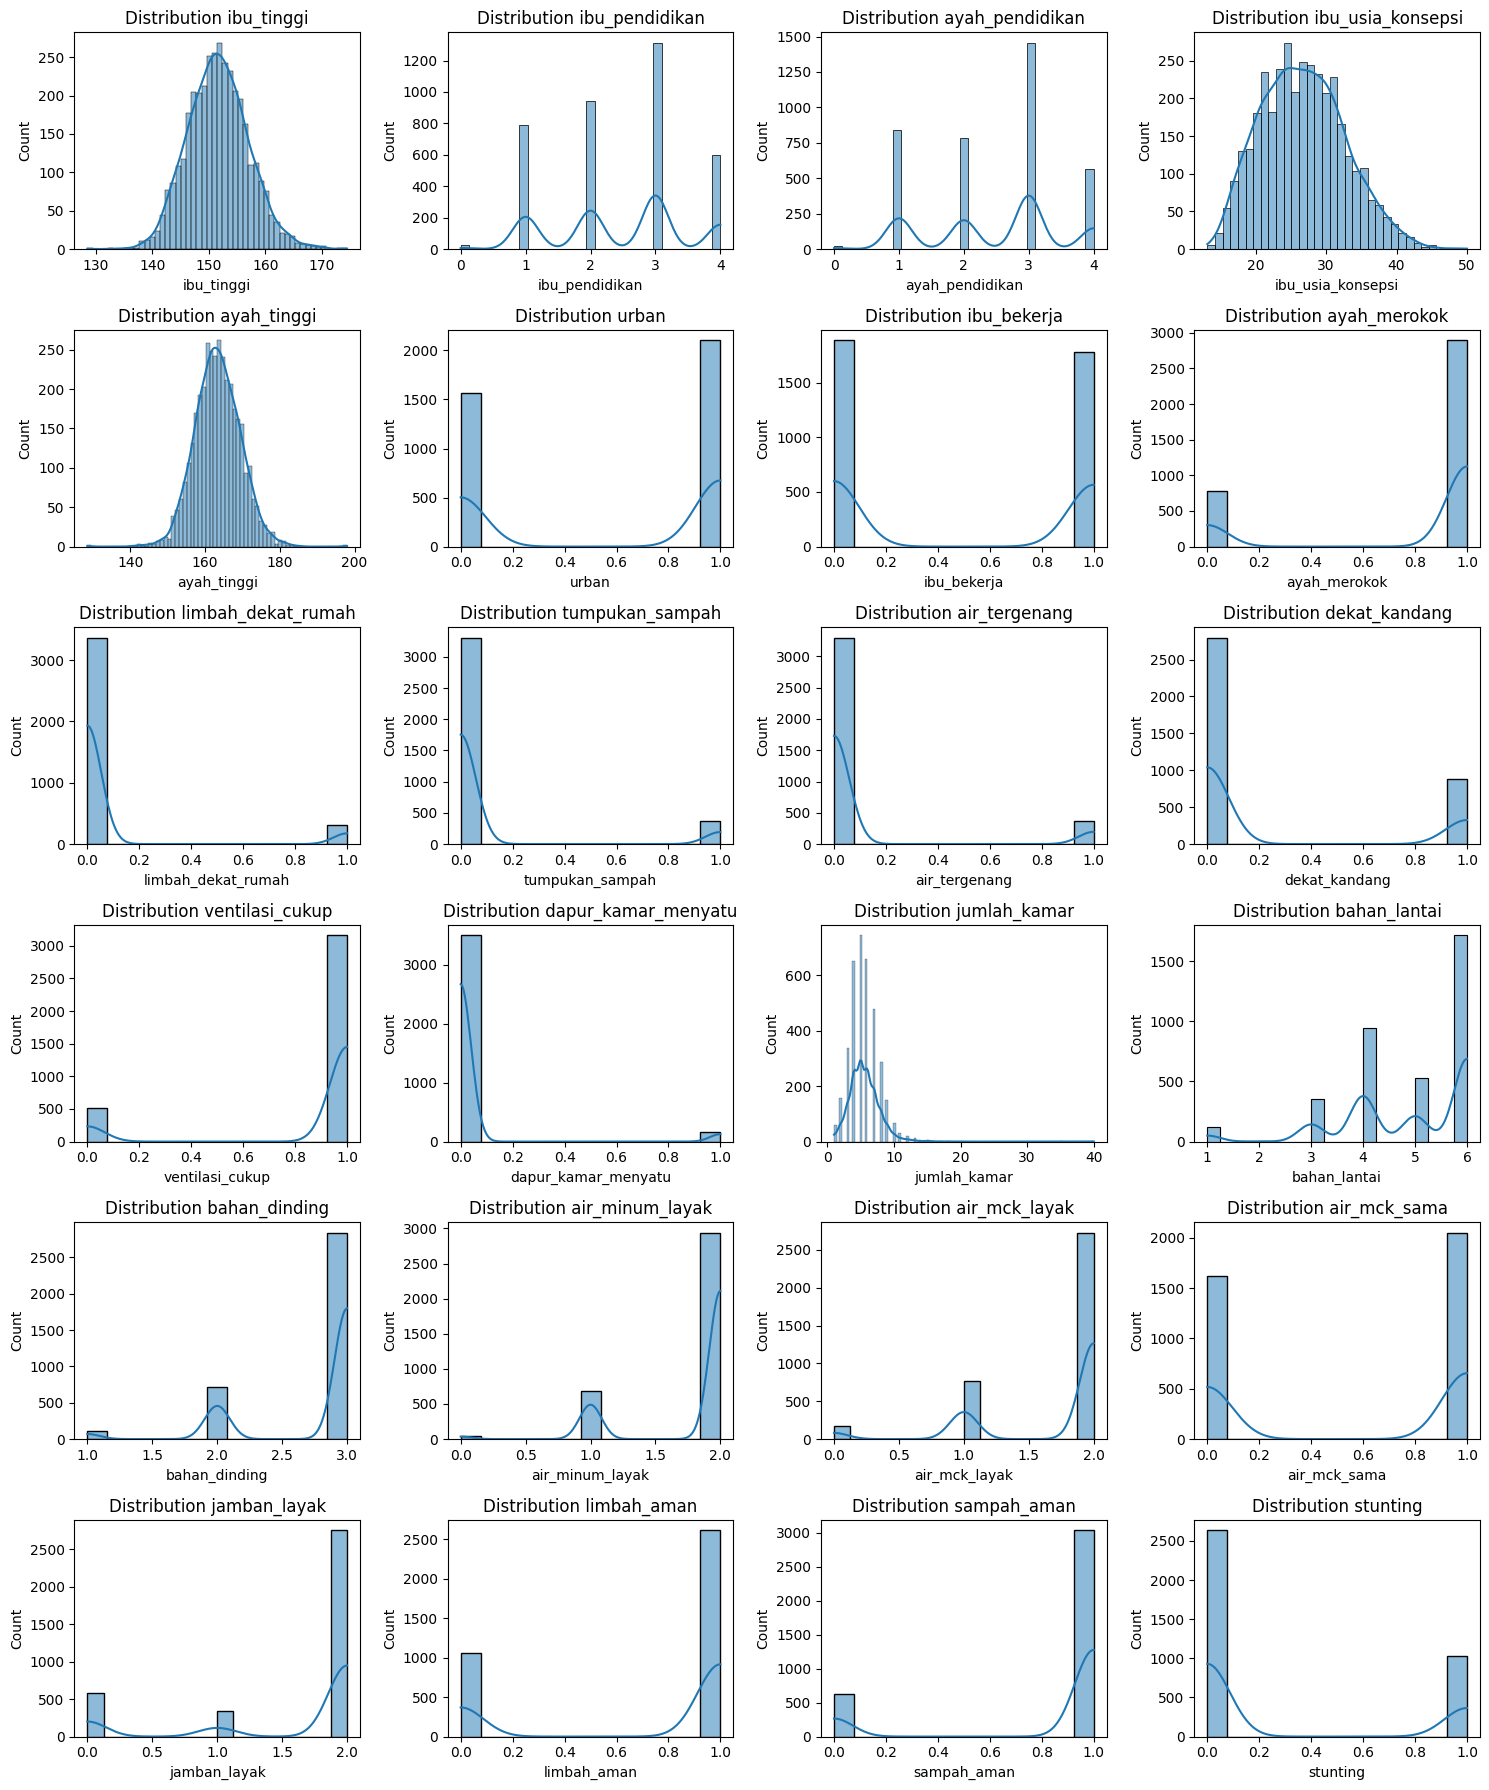

In [16]:
data_understanding(df_clean,"stunting")

## Split Data

In [17]:
# Pembagian data
x = df_clean.drop(columns='stunting')
y = df_clean['stunting']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## PCA

In [18]:
wealth_cols = ["bahan_lantai", "bahan_dinding", "jumlah_kamar"]

sc_kk  = StandardScaler().fit(X_train[wealth_cols])
pca_kk = PCA(n_components=1).fit(sc_kk.transform(X_train[wealth_cols]))

arah = 1.0 if pca_kk.components_[0].sum() > 0 else -1.0

def skor_kemakmuran(X):
    return pca_kk.transform(sc_kk.transform(X[wealth_cols]))[:, 0] * arah

batas = np.quantile(skor_kemakmuran(X_train), [1/3, 2/3])

def kelompok_kemakmuran(X):
    return pd.Series(
        pd.cut(skor_kemakmuran(X), bins=[-np.inf, batas[0], batas[1], np.inf],
               labels=["rendah", "sedang", "tinggi"]),
        index=X.index)

# Report
print(f"arah dibalik: {'ya' if arah < 0 else 'tidak'}")
print(f"PC1: {pca_kk.explained_variance_ratio_[0]*100:.1f}% variasi")
print("bobot:", "  ".join(f"{c}={w:+.3f}"
      for c, w in zip(wealth_cols, pca_kk.components_[0]*arah)))

for nama, X, y in [("Data train", X_train, y_train), ("Data test", X_test, y_test)]:
    k = kelompok_kemakmuran(X)
    prevalensi = y.mean()
    print(f"{nama} (prevalensi {prevalensi*100:.1f}%)")
    for g in ["rendah", "sedang", "tinggi"]:
        m = k == g
        print(f"kemakmuran {g:7s} n:{m.sum():5,} ({m.mean()*100:4.1f}%) stunting: {y[m].mean()*100:5.1f}%  lift: {y[m].mean()/prevalensi:.2f}")

arah dibalik: tidak
PC1: 59.2% variasi
bobot: bahan_lantai=+0.619  bahan_dinding=+0.621  jumlah_kamar=+0.481
Data train (prevalensi 28.2%)
kemakmuran rendah  n:  910 (35.4%) stunting:  34.9%  lift: 1.24
kemakmuran sedang  n:  892 (34.7%) stunting:  24.9%  lift: 0.88
kemakmuran tinggi  n:  768 (29.9%) stunting:  24.0%  lift: 0.85
Data test (prevalensi 28.2%)
kemakmuran rendah  n:  386 (35.0%) stunting:  35.5%  lift: 1.26
kemakmuran sedang  n:  383 (34.8%) stunting:  23.5%  lift: 0.83
kemakmuran tinggi  n:  333 (30.2%) stunting:  25.2%  lift: 0.89


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Association Rule Mining

In [19]:
def binning(df):
    _data = df.copy()

    _data["ibu_tinggi_kat"] = pd.cut(
        _data["ibu_tinggi"],
        bins=[0, 150, 161, 999],
        labels=["<150", "150-160", ">160"],
        right=False,
    )

    _data["ayah_tinggi_kat"] = pd.cut(
        _data["ayah_tinggi"],
        bins=[0, 160, 171, 999],
        labels=["<160", "160-170", ">170"],
        right=False,
    )

    _data["ibu_usia_kat"] = pd.cut(
        _data["ibu_usia_konsepsi"],
        bins=[0, 20, 36, 99],
        labels=["<20", "20-35", ">35"],
        right=False,
    )

    _data = _data.drop(columns=["ibu_tinggi", "ayah_tinggi", "ibu_usia_konsepsi"])
    return _data

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
X_train_arm = binning(X_train)
X_test_arm  = binning(X_test)

# verifikasi
prevalensi = y_train.mean()
print(f"prevalensi data latih: {prevalensi*100:.1f}%\n")
for kol in ["ibu_tinggi_kat", "ayah_tinggi_kat", "ibu_usia_kat"]:
    print(kol)
    for kat in X_train_arm[kol].cat.categories:
        m = X_train_arm[kol] == kat
        n = m.sum()
        p = y_train[m].mean()
        print(f"   {kat:12s} n: {n:5,} ({n/len(X_train_arm)*100:5.1f}%) stunting: {p*100:5.1f}%  lift: {p/prevalensi:.2f}")

prevalensi data latih: 28.2%

ibu_tinggi_kat
   <150         n:   942 ( 36.7%) stunting:  38.3%  lift: 1.36
   150-160      n: 1,514 ( 58.9%) stunting:  23.1%  lift: 0.82
   >160         n:   114 (  4.4%) stunting:  11.4%  lift: 0.40
ayah_tinggi_kat
   <160         n:   724 ( 28.2%) stunting:  38.0%  lift: 1.35
   160-170      n: 1,581 ( 61.5%) stunting:  25.7%  lift: 0.91
   >170         n:   265 ( 10.3%) stunting:  15.8%  lift: 0.56
ibu_usia_kat
   <20          n:   352 ( 13.7%) stunting:  37.5%  lift: 1.33
   20-35        n: 2,052 ( 79.8%) stunting:  26.6%  lift: 0.94
   >35          n:   166 (  6.5%) stunting:  28.3%  lift: 1.01


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
for arm, mentah in [(X_train_arm, X_train), (X_test_arm, X_test)]:
    arm["kemakmuran"] = kelompok_kemakmuran(mentah)
    arm.drop(columns=wealth_cols, inplace=True, errors="ignore")   # buang penyusun wealth index

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
def transaction_encode(X, y):
    _data = X.copy()

    _data["stunting"] = y.values

    _data = _data.astype(str)
    keranjang = pd.get_dummies(_data, prefix_sep="=")
    return keranjang

keranjang_train = transaction_encode(X_train_arm, y_train)

print("bentuk     :", keranjang_train.shape)
print("jumlah item:", keranjang_train.shape[1])
print(f"="*90,"\n")
print("Top 10 items paling sering:")
print((keranjang_train.mean()*100).sort_values(ascending=False).head(10).round(1).to_string())
print(f"="*90,"\n")
print("Top 10 items paling jarang:")
print((keranjang_train.mean()*100).sort_values().head(10).round(1).to_string())

bentuk     : (2570, 57)
jumlah item: 57

Top 10 items paling sering:
dapur_kamar_menyatu=0    95.9
limbah_dekat_rumah=0     91.5
air_tergenang=0          89.7
tumpukan_sampah=0        89.7
ventilasi_cukup=1        86.3
sampah_aman=1            82.7
air_minum_layak=2        80.5
ibu_usia_kat=20-35       79.8
ayah_merokok=1           79.3
dekat_kandang=0          75.8

Top 10 items paling jarang:
ayah_pendidikan=0         0.6
ibu_pendidikan=0          0.7
air_minum_layak=0         1.4
dapur_kamar_menyatu=1     4.1
ibu_tinggi_kat=>160       4.4
air_mck_layak=0           5.1
ibu_usia_kat=>35          6.5
limbah_dekat_rumah=1      8.5
jamban_layak=1            9.3
air_tergenang=1          10.3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [23]:
# buang item yang terlalu sering (tidak informatif + buat ledakan kombinasi) dan yang terlalu jarang
sup = keranjang_train.mean()
item_pakai = sup[(sup >= 0.03) & (sup <= 0.85)].index.tolist()

target_col = [c for c in keranjang_train.columns if c.startswith("stunting=")]
item_pakai = sorted(set(item_pakai) | set(target_col))

keranjang_pakai = keranjang_train[item_pakai]
print(f"item: {keranjang_train.shape[1]} -> {keranjang_pakai.shape[1]}")

item: 57 -> 49


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
TARGET = frozenset({"stunting=1"})

def aturan_terarah(itemsets, n_transaksi, target=TARGET, min_lift=1.0):

    sup = dict(zip(itemsets["itemsets"], itemsets["support"]))
    sup_target = sup[target]

    baris = []
    for iset, s in sup.items():
        if not target <= iset or len(iset) == len(target):
            continue
        antecedents = iset - target
        confidence = s / sup[antecedents]
        lift = confidence / sup_target
        if lift >= min_lift:
            baris.append({
                "antecedents": antecedents,
                "n_rt": int(round(s * n_transaksi)),
                "support": s, "confidence": confidence, "lift": lift,
            })
    return pd.DataFrame(baris).sort_values("lift", ascending=False)


itemsets = fpgrowth(
    keranjang_pakai,
    min_support=0.02,
    use_colnames=True,
    max_len=5,
)
print(f"jumlah itemset: {len(itemsets):,}")

rules_target = aturan_terarah(itemsets, n_transaksi=len(keranjang_pakai))
print(f"aturan menuju stunting=1: {len(rules_target):,}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


jumlah itemset: 125,771
aturan menuju stunting=1: 4,506


In [25]:
top = 100
c = Counter(item for s in rules_target.head(100)["antecedents"] for item in s)
print(f"faktor paling sering muncul di 100 aturan teratas:")
for item, jumlah in c.most_common(12):
    print(f"  {item:34s} {jumlah:3d} dari 100")

keranjang_test = transaction_encode(X_test_arm, y_test)
keranjang_test = keranjang_test.reindex(columns=keranjang_train.columns, fill_value=False)

def uji_di_test(rules, keranjang, target="stunting=1", n_top=20):
    y_tgt = keranjang[target]
    prev = y_tgt.mean()
    hasil = []
    for _, r in rules.head(n_top).iterrows():
        antecedents = sorted(r["antecedents"])
        cocok = keranjang[antecedents].all(axis=1)      # baris yang memenuhi SEMUA item
        n_cocok = int(cocok.sum())
        conf = y_tgt[cocok].mean() if n_cocok else np.nan
        hasil.append({
            "antecedents": " + ".join(antecedents),
            "lift_train": r["lift"], "n_train": r["n_rt"],
            "lift_test": conf/prev if n_cocok else np.nan, "n_test": n_cocok,
        })
    return pd.DataFrame(hasil)

print(f"\nprevalensi data uji: {y_test.mean()*100:.1f}%")

hasil = uji_di_test(rules_target, keranjang_test, n_top=300)
hasil["selisih"] = hasil.lift_test - hasil.lift_train

kriteria_list = 1.5
kriteria_n    = 30

lolos = hasil[(hasil.lift_test >= kriteria_list) & (hasil.n_test >= kriteria_n)]
print(f"{len(hasil)} aturan diuji: {len(lolos)} lolos kriteria")

lolos.sort_values("lift_test", ascending=False).head(15).round(3)

faktor paling sering muncul di 100 aturan teratas:
  ibu_tinggi_kat=<150                 63 dari 100
  ayah_tinggi_kat=<160                54 dari 100
  urban=0                             43 dari 100
  air_mck_sama=1                      24 dari 100
  ayah_merokok=1                      22 dari 100
  kemakmuran=rendah                   22 dari 100
  sampah_aman=1                       17 dari 100
  jamban_layak=0                      15 dari 100
  ayah_pendidikan=1                   14 dari 100
  dekat_kandang=0                     14 dari 100
  air_minum_layak=1                   12 dari 100
  ibu_pendidikan=1                    10 dari 100

prevalensi data uji: 28.2%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


300 aturan diuji: 188 lolos kriteria


,antecedents,lift_train,n_train,lift_test,n_test,selisih
2,ayah_pendidikan=1 + ayah_tinggi_kat=<160 + kem...,2.065,57,2.453,52,0.388
47,ayah_merokok=1 + ayah_pendidikan=1 + ayah_ting...,1.790,58,2.314,49,0.524
74,ayah_pendidikan=1 + ayah_tinggi_kat=<160 + urb...,1.761,65,2.238,57,0.477
23,ayah_tinggi_kat=<160 + ibu_tinggi_kat=<150 + k...,1.840,71,2.184,73,0.345
18,ayah_merokok=1 + ayah_tinggi_kat=<160 + ibu_ti...,1.849,62,2.172,62,0.322
9,air_minum_layak=2 + ibu_tinggi_kat=<150 + jamb...,1.895,55,2.067,36,0.172
160,ayah_merokok=1 + ayah_pendidikan=1 + ayah_ting...,1.693,83,2.056,81,0.363
16,ayah_tinggi_kat=<160 + dekat_kandang=0 + ibu_t...,1.858,56,2.051,57,0.194
38,ayah_tinggi_kat=<160 + ibu_tinggi_kat=<150 + k...,1.807,56,2.044,52,0.237
6,ayah_tinggi_kat=<160 + ibu_tinggi_kat=<150 + k...,1.936,54,2.036,47,0.099


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Outlier Handling

In [26]:
non_binnary_cols = ["ibu_tinggi", "ayah_tinggi", "ibu_usia_konsepsi", "kemakmuran_skor"]
class IQRCapper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = np.array(X)
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - 1.5 * IQR
        self.upper_ = Q3 + 1.5 * IQR
        return self

    def transform(self, X, y=None):
        X = np.array(X).copy()
        for i in range(X.shape[1]):
            X[:, i] = np.clip(X[:, i], self.lower_[i], self.upper_[i])
        return X

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
class IndeksKemakmuran(BaseEstimator, TransformerMixin):
    def __init__(self, kolom=("bahan_lantai", "bahan_dinding", "jumlah_kamar")):
        self.kolom = kolom

    def fit(self, X, y=None):
        self.kolom_ = list(self.kolom)
        M = X[self.kolom_]
        self.scaler_ = StandardScaler().fit(M)
        self.pca_ = PCA(n_components=1).fit(self.scaler_.transform(M))
        self.arah_ = 1.0 if self.pca_.components_[0].sum() > 0 else -1.0
        return self

    def transform(self, X):
        X = X.copy()
        X["kemakmuran_skor"] = self.pca_.transform(
            self.scaler_.transform(X[self.kolom_]))[:, 0] * self.arah_
        return X.drop(columns=self.kolom_)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Scaling

In [28]:
continous_cols = ["ibu_tinggi", "ayah_tinggi", "ibu_usia_konsepsi", "kemakmuran_skor"]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('capper', IQRCapper()),
        ('scaler', StandardScaler())
    ]), continous_cols)
], remainder='passthrough')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Modeling

In [29]:
candidates = {

    'Random Forest': {
        'classifier': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'classifier__n_estimators': [200],
            'classifier__max_depth': [6, 10, None],
            'classifier__min_samples_leaf': [5, 15],
            'classifier__class_weight': ['balanced']
        }
    },

    'XGBoost': {
        'classifier': XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
        ),
        'params': {
            'classifier__n_estimators':  [200, 400],
            'classifier__max_depth':     [3, 5, 7],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__subsample':     [0.8],
        }
    },

    'SVM': {
        'classifier': SVC(random_state=42, probability=True),
        'params': {
            'classifier__C': [0.5, 1, 10],
            'classifier__kernel': ['rbf'],
            'classifier__gamma': ['scale'],
            'classifier__class_weight': ['balanced']
        }
    }
}

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, config in candidates.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)

    pipeline = Pipeline([
        ('kemakmuran',   IndeksKemakmuran()),   # PCA belajar ulang tiap fold
        ('preprocessor', preprocessor),
        ('classifier',   config['classifier'])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=cv,
        scoring='average_precision',
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)
    y_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    results[name] = {
        'best_params':    grid.best_params_,
        'cv_score':       round(grid.best_score_, 4),
        'test_prauc':     round(average_precision_score(y_test, y_proba), 4),
        'test_recall':    round(recall_score(y_test, y_pred), 4),
        'test_f1':        round(f1_score(y_test, y_pred), 4),
        'best_estimator': grid.best_estimator_,
        'y_proba':        y_proba,
        'y_pred':         y_pred
    }

    print(f"Best Params : {grid.best_params_}")
    print(f"CV PR-AUC   : {grid.best_score_:.4f}")
    print(f"Test PR-AUC : {results[name]['test_prauc']}")
    print(f"Test Recall : {results[name]['test_recall']}")


Training: Random Forest
Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Best Params : {'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
CV PR-AUC   : 0.4612
Test PR-AUC : 0.4676
Test Recall : 0.4598

Training: XGBoost
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params : {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
CV PR-AUC   : 0.4436
Test PR-AUC : 0.429
Test Recall : 0.582

Training: SVM
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Params : {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
CV PR-AUC   : 0.4424
Test PR-AUC : 0.4674
Test Recall : 0.1479


# Evaluation

In [31]:
recall_target = 0.65

for name, v in results.items():
    proba_train = cross_val_predict(v['best_estimator'], X_train, y_train,cv=cv, method='predict_proba')[:, 1]

    prec, rec, thr = precision_recall_curve(y_train, proba_train)
    layak = thr[rec[:-1] >= recall_target]
    v['ambang'] = layak.max() if len(layak) else 0.0
    v['y_pred_ambang'] = (v['y_proba'] >= v['ambang']).astype(int)

    print(f"\n{'='*55}")
    print(f"{name}   ambang terpilih = {v['ambang']:.3f}")
    print('='*55)
    for label, t in [("SEBELUM (ambang 0,5)", 0.5), ("SESUDAH (ambang baru)", v['ambang'])]:
        pred = (v['y_proba'] >= t).astype(int)
        print(f"  {label:22s} recall={recall_score(y_test, pred):.3f}  "
              f"precision={precision_score(y_test, pred, zero_division=0):.3f}  "
              f"ditandai={pred.sum()} anak")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Random Forest   ambang terpilih = 0.402
  SEBELUM (ambang 0,5)   recall=0.460  precision=0.460  ditandai=311 anak
  SESUDAH (ambang baru)  recall=0.682  precision=0.390  ditandai=544 anak

XGBoost   ambang terpilih = 0.451
  SEBELUM (ambang 0,5)   recall=0.582  precision=0.389  ditandai=465 anak
  SESUDAH (ambang baru)  recall=0.669  precision=0.375  ditandai=555 anak

SVM   ambang terpilih = 0.269
  SEBELUM (ambang 0,5)   recall=0.148  precision=0.630  ditandai=73 anak
  SESUDAH (ambang baru)  recall=0.659  precision=0.388  ditandai=528 anak


In [32]:
df_results = pd.DataFrame({
    name: {
        'CV PR-AUC': v['cv_score'],
        'Test PR-AUC': v['test_prauc'],
        'Ambang': round(v['ambang'], 3),
        'Recall (0,5)': round(recall_score(y_test, v['y_pred']), 4),
        'Recall (ambang)': round(recall_score(y_test, v['y_pred_ambang']), 4),
        'Precision (ambang)': round(precision_score(y_test, v['y_pred_ambang'], zero_division=0), 4),
        'F1 (ambang)': round(f1_score(y_test, v['y_pred_ambang']), 4),
    }
    for name, v in results.items()
}).T.sort_values('Test PR-AUC', ascending=False)

print("Perbandingan Model")
display(df_results)

Perbandingan Model


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,CV PR-AUC,Test PR-AUC,Ambang,"Recall (0,5)",Recall (ambang),Precision (ambang),F1 (ambang)
Random Forest,0.4612,0.4676,0.402,0.4598,0.6817,0.3897,0.4959
SVM,0.4424,0.4674,0.269,0.1479,0.6592,0.3883,0.4887
XGBoost,0.4436,0.4290,0.451,0.5820,0.6688,0.3748,0.4804


In [33]:
for name, v in results.items():
    print(f"\n{'='*50}")
    print(f"Classification Report: {name}")
    print('='*50)
    print(classification_report(
        y_test,
        v['y_pred_ambang'],
        zero_division=0
    ))


Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.82      0.58      0.68       791
           1       0.39      0.68      0.50       311

    accuracy                           0.61      1102
   macro avg       0.61      0.63      0.59      1102
weighted avg       0.70      0.61      0.63      1102


Classification Report: XGBoost
              precision    recall  f1-score   support

           0       0.81      0.56      0.66       791
           1       0.37      0.67      0.48       311

    accuracy                           0.59      1102
   macro avg       0.59      0.62      0.57      1102
weighted avg       0.69      0.59      0.61      1102


Classification Report: SVM
              precision    recall  f1-score   support

           0       0.82      0.59      0.69       791
           1       0.39      0.66      0.49       311

    accuracy                           0.61      1102
   macro avg       0.60      0

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# SHAP

In [34]:
!pip install shap -q

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [35]:
selected_model = 'Random Forest'
model = results[selected_model]['best_estimator']

kol_setelah_kemakmuran = list(
    model.named_steps['kemakmuran'].transform(X_test.head(2)).columns
)
nama_fitur = continous_cols + [c for c in kol_setelah_kemakmuran if c not in continous_cols]

X_trans = model[:-1].transform(X_test)
assert X_trans.shape[1] == len(nama_fitur), "jumlah kolom tidak cocok"
X_shap = pd.DataFrame(X_trans, columns=nama_fitur)

explainer = shap.TreeExplainer(model.named_steps['classifier'])
sv = explainer.shap_values(X_shap)

if isinstance(sv, list): shap_values = sv[1] # ambil kelas stunting
elif sv.ndim == 3: shap_values = sv[:, :, 1]
else: shap_values = sv

print(f"Shape: {shap_values.shape}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Shape: (1102, 21)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


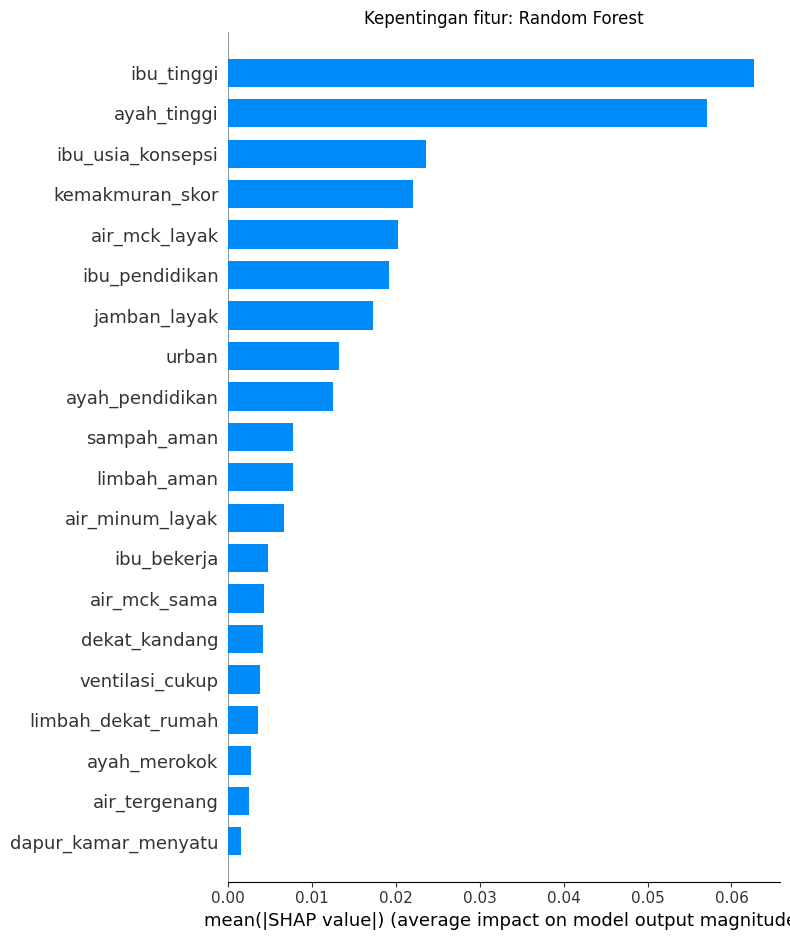

In [36]:
# Urutan kepentingan fitur
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title(f"Kepentingan fitur: {selected_model}")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


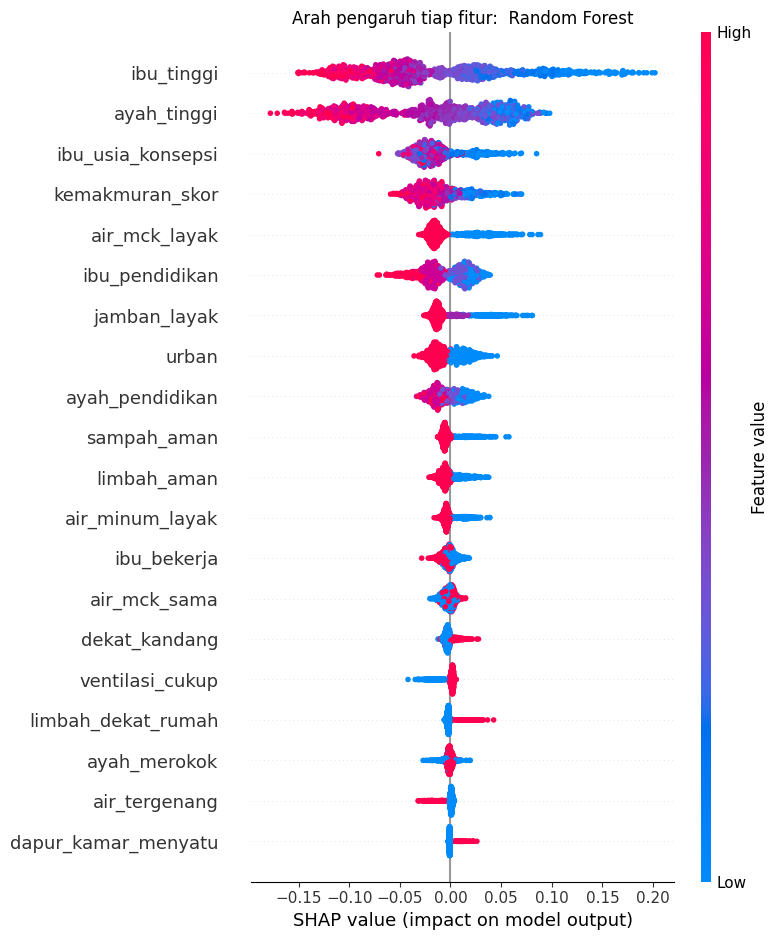

In [37]:
shap.summary_plot(shap_values, X_shap, show=False)
plt.title(f"Arah pengaruh tiap fitur:  {selected_model}")
plt.tight_layout()
plt.show()

In [41]:
DOMAIN = {
    "Karakteristik orang tua": [
        "ibu_tinggi", "ayah_tinggi", "ibu_pendidikan",
        "ayah_pendidikan", "ibu_usia_konsepsi", "ayah_merokok", "ibu_bekerja",
    ],
    "Kondisi hunian": [
        "kemakmuran_skor", "ventilasi_cukup", "dapur_kamar_menyatu",
    ],
    "Air & sanitasi (WASH)": [
        "air_minum_layak", "air_mck_layak", "air_mck_sama",
        "jamban_layak", "limbah_aman", "sampah_aman",
    ],
    "Lingkungan sekitar": [
        "urban", "dekat_kandang",
        "limbah_dekat_rumah", "tumpukan_sampah", "air_tergenang",
    ],
}

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [42]:
imp = pd.Series(np.abs(shap_values).mean(0), index=nama_fitur)
porsi = imp / imp.sum() * 100

print("kepentingan tiap fitur:")
for f, v in porsi.sort_values(ascending=False).items():
    print(f"   {f:22s} {v:5.1f}%")

print("\nper domain:")
for d, cols in DOMAIN.items():
    ada = [c for c in cols if c in porsi.index]
    print(f"   {d:26s} {porsi[ada].sum():5.1f}%")

kepentingan tiap fitur:
   ibu_tinggi              21.0%
   ayah_tinggi             19.1%
   ibu_usia_konsepsi        7.9%
   kemakmuran_skor          7.4%
   air_mck_layak            6.8%
   ibu_pendidikan           6.4%
   jamban_layak             5.8%
   urban                    4.4%
   ayah_pendidikan          4.2%
   sampah_aman              2.6%
   limbah_aman              2.6%
   air_minum_layak          2.2%
   ibu_bekerja              1.6%
   air_mck_sama             1.4%
   dekat_kandang            1.4%
   ventilasi_cukup          1.3%
   limbah_dekat_rumah       1.2%
   ayah_merokok             0.9%
   air_tergenang            0.8%
   dapur_kamar_menyatu      0.5%
   tumpukan_sampah          0.4%

per domain:
   Karakteristik orang tua     61.2%
   Kondisi hunian               9.2%
   Air & sanitasi (WASH)       21.4%
   Lingkungan sekitar           8.3%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [43]:
import joblib, json

joblib.dump(results['Random Forest']['best_estimator'], 'model_stunting.pkl')

rentang = {}
for kol in X_train.columns:
    v = X_train[kol].dropna()
    rentang[kol] = {
        'min':float(v.min()),
        'max':float(v.max()),
        'nilai_unik': sorted(map(float, v.unique())) if v.nunique() <= 30 else None,
        'modus':float(v.mode()[0]),
    }

meta = {
    'ambang':float(results['Random Forest']['ambang']),
    'target_recall':0.65,
    'kolom_input':list(X_train.columns),
    'kolom_setelah_transform': nama_fitur,
    'prevalensi':float(y_train.mean()),
    'metrik_test': {
        'pr_auc':float(results['Random Forest']['test_prauc']),
        'recall':0.632,
        'precision': 0.376,
    },
    'rentang': rentang,
}

with open('meta_model.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("tersimpan: model_stunting.pkl, meta_model.json")
print(f"jumlah kolom: {len(meta['kolom_input'])}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


tersimpan: model_stunting.pkl, meta_model.json
jumlah kolom: 23
